In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')


/kaggle/input/datasets/mnassrib/jena-climate/jena_climate_2009_2016.csv


In [22]:
import torch
import numpy as np

print(f"PyTorch Version: {torch.__version__}")

# 1. The Divine Fire: Checking if the GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

print("\n--- NumPy vs PyTorch Practice ---")

# 2. Creating a 2D array in NumPy (something you know)
np_array = np.array([[1.0, 2.0], [3.0, 4.0]])




















print(f"NumPy Array:\n{np_array} (Type: {type(np_array)})")

# 3. Forging a PyTorch Tensor from that NumPy array
py_tensor = torch.from_numpy(np_array)
print(f"PyTorch Tensor:\n{py_tensor} (Type: {type(py_tensor)})")

# 4. Sending your tensor to the GPU warrior
if torch.cuda.is_available():
    gpu_tensor = py_tensor.to(device)
    print(f"\nTensor successfully sent to GPU! Device property: {gpu_tensor.device}")

PyTorch Version: 2.10.0+cpu
Using device: cpu

--- NumPy vs PyTorch Practice ---
NumPy Array:
[[1. 2.]
 [3. 4.]] (Type: <class 'numpy.ndarray'>)
PyTorch Tensor:
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64) (Type: <class 'torch.Tensor'>)


# Testing for GPU

In [23]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

dataset_path = '/kaggle/input/datasets/mnassrib/jena-climate/jena_climate_2009_2016.csv'
df = pd.read_csv(dataset_path)

#sampling from 10 minute to 1 hour intervals as our requirement is in hours
#starting from 5th index,we take every 6th row as i hour is 60 minutes
df = df.iloc[5::6].reset_index(drop=True)

# we drop'Date Time' string column
features = df[['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']].values

#normalizing the data to prevent exploding gradient
scaler = StandardScaler()
#Atmospheric Pressure is around 1000 mbar, but Wind Speed is around 2 m/s. If you feed these raw numbers into a neural network, the massive pressure numbers will completely dominate the math, and the network will ignore the wind speed entirely
features_scaled = scaler.fit_transform(features)

# IMPORTING THE JENA CLIMATE DATASET

In [24]:
X = []
y = []

seq_length = 72
forecast_offset = 12
temp_index = 1 # 'T (degC)' is at index 1 in our features list

print("sliding windows")

for i in range(len(features_scaled) - seq_length - forecast_offset):
    # The 72 hour input sequence of 14 features
    window = features_scaled[i : i + seq_length]
    
    #actual temperatures for logical comparison
    current_temp = features[i + seq_length - 1, temp_index]
    future_temp = features[i + seq_length + forecast_offset - 1, temp_index]
    
    #1 if hotter,0 if equal or colder
    target = 1 if future_temp > current_temp else 0
    #this is done to evaluate classification metrics(if predicted temperature is hotter or colder than actual temperature)
    
    X.append(window)
    y.append(target)

#lists to tensors
X_tensor = torch.tensor(np.array(X), dtype=torch.float32)
y_tensor = torch.tensor(np.array(y), dtype=torch.long)

print(f"Total Number Sequences : {len(X_tensor)}")
print(f"Shape of X_tensor: {X_tensor.shape} -> [Batches, Sequence Length, Features]")

sliding windows
Total Number Sequences : 70007
Shape of X_tensor: torch.Size([70007, 72, 14]) -> [Batches, Sequence Length, Features]


# Preparing the Sliding Window

In [25]:
class JenaDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
        
    def __len__(self):
        return len(self.sequences)
        
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

#we split the data chronologically and seperate test and train set (80% goes for training and 20% goes for testing in chronological order)

split_idx = int(len(X_tensor) * 0.8)

train_dataset = JenaDataset(X_tensor[:split_idx], y_tensor[:split_idx])
test_dataset = JenaDataset(X_tensor[split_idx:], y_tensor[split_idx:])

#dataloaders
#batch size 256 is ok for 1D tensors
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

#verification
sequences, labels = next(iter(train_loader))
print(f"First Batch X shape: {sequences.shape}")
print(f"First Batch Y shape: {labels.shape}")
print(sequences[0][0])#will have 14 elements in the tensor 

First Batch X shape: torch.Size([256, 72, 14])
First Batch Y shape: torch.Size([256])
tensor([ 1.1039, -0.1449, -0.2320,  0.4805,  1.4380, -0.3445,  0.3217, -0.8191,
         0.2927,  0.2951,  0.3732, -0.0161, -0.0209,  0.5450])


# Preparing the dataloders

# THE 5 GOVERNING EQUATIONS OF LSTM
**Forget Gate ($f_t$): $f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$**

**Input Gate ($i_t$): $i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$** 

**Candidate State ($\tilde{C}_t$): $\tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$**

**Cell State Update ($C_t$): $C_t = f_t * C_{t-1} + i_t * \tilde{C}_t$**

**Output Gate & Hidden State ($h_t$): $o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \rightarrow h_t = o_t * \tanh(C_t)$**

In [26]:
import torch
import torch.nn as nn

class LSTM(nn.Module):
    def __init__(self, input_size=14, hidden_size=64, num_classes=6):
        super().__init__()
        self.input_size = input_size
        
        # hidden dimension should be between 32 and 256
        self.hidden_size = hidden_size 
        
        # We concatenate the current input (x_t) and previous hidden state (h_{t-1})
        # So the weight matrices must accept the combined size
        combined_size = input_size + hidden_size
        
        # Forget Gate: decides what past memory to erase
        self.W_f = nn.Linear(combined_size, hidden_size)
        
        # Input Gate: decides what new information to let in
        self.W_i = nn.Linear(combined_size, hidden_size)
        
        # Candidate Cell State: the new potential information to add
        self.W_c = nn.Linear(combined_size, hidden_size)
        
        #  Output Gate: Decides what part of the memory becomes the new hidden state
        self.W_o = nn.Linear(combined_size, hidden_size)
        
        # Final Classifier (1 = Hotter, 0 = Colder or Same)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape gives [Batch_Size, Sequence_Length, Features],example [256, 72, 14]
        batch_size, seq_len, _ = x.size()
        device = x.device
        
        # initializing both hidden and cell state to all zeroes
        h_t = torch.zeros(batch_size, self.hidden_size).to(device)
        c_t = torch.zeros(batch_size, self.hidden_size).to(device)
        
        # Sliding through the 72 hours step by step
        for t in range(seq_len):
            #extracting the weather features for the current hour t
            x_t = x[:, t, :] 
            
            #concatenate current input and previous hidden state horizontally
            combined = torch.cat((x_t, h_t), dim=1)
            
            # applying the 5 LSTM equations mentioned above 
            
            #Forget Gate (sigmoid function brings the value between 0 and 1, 0 = forgetten completely)
            f_t = torch.sigmoid(self.W_f(combined))
            
            #Input Gate
            i_t = torch.sigmoid(self.W_i(combined))
            
            #Candidate cell state (Tanh function brings the value between -1 and 1)
            c_tilde = torch.tanh(self.W_c(combined))
            
            #Update cell state(Long Term Memory)
            c_t = (f_t * c_t) + (i_t * c_tilde)
            
            #output gate and the final hidden state updation
            o_t = torch.sigmoid(self.W_o(combined))
            h_t = o_t * torch.tanh(c_t)
            
        # after looping through all 72 hours, we take the hidden state
        # and pass it to our fully connected layer to make the prediction
        out = self.fc(h_t)
        return out

model=LSTM().to(device)
print(model)

LSTM(
  (W_f): Linear(in_features=78, out_features=64, bias=True)
  (W_i): Linear(in_features=78, out_features=64, bias=True)
  (W_c): Linear(in_features=78, out_features=64, bias=True)
  (W_o): Linear(in_features=78, out_features=64, bias=True)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)


# Building The LSTM

--- Beginning of Training (Training the model) ---
  [Epoch 1, Batch 100] Loss: 0.902
  [Epoch 1, Batch 200] Loss: 0.405
Epoch [1/10] | Train Loss: 0.6318, Train Acc: 71.88% | Val Loss: 0.3793, Val Acc: 82.38%
  [Epoch 2, Batch 100] Loss: 0.377
  [Epoch 2, Batch 200] Loss: 0.367
Epoch [2/10] | Train Loss: 0.3716, Train Acc: 82.96% | Val Loss: 0.3643, Val Acc: 83.63%
  [Epoch 3, Batch 100] Loss: 0.364
  [Epoch 3, Batch 200] Loss: 0.359
Epoch [3/10] | Train Loss: 0.3610, Train Acc: 83.39% | Val Loss: 0.3484, Val Acc: 84.62%
  [Epoch 4, Batch 100] Loss: 0.354
  [Epoch 4, Batch 200] Loss: 0.349
Epoch [4/10] | Train Loss: 0.3518, Train Acc: 83.83% | Val Loss: 0.3445, Val Acc: 84.87%
  [Epoch 5, Batch 100] Loss: 0.350
  [Epoch 5, Batch 200] Loss: 0.344
Epoch [5/10] | Train Loss: 0.3461, Train Acc: 84.12% | Val Loss: 0.3403, Val Acc: 84.98%
  [Epoch 6, Batch 100] Loss: 0.345
  [Epoch 6, Batch 200] Loss: 0.342
Epoch [6/10] | Train Loss: 0.3438, Train Acc: 84.31% | Val Loss: 0.3344, Val Acc: 85

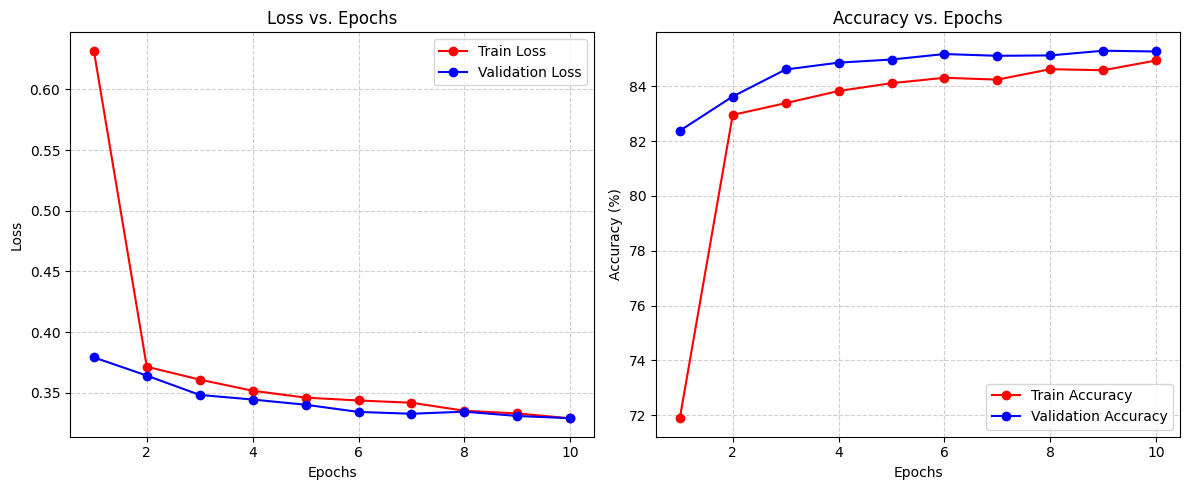

In [27]:
#  Baseline Training
import torch.optim as optim
import matplotlib.pyplot as plot
loss_history=[]
train_acc_history = []
val_loss_history = []
val_acc_history = []
batch_loss_history=[]

# 1.Loss Function and Optimizer
# CrossEntropyLoss is standard for multi-class classification (digits 0-9)
criterion = nn.CrossEntropyLoss()#softmax(e^x by summation e^x)+negative-log-likelihood
#loss=- summation(ytrue*log(pmodel)),,,loss=-log(pcorrect)

# Adam is a highly efficient optimizer that dynamically adjusts the learning rate
optimizer = optim.Adam(model.parameters(), lr=0.001)#lr=learning rate

# 2.Training Loop

#An Epoch is one complete pass through the entire library
epochs=10
print("--- Beginning of Training (Training the model) ---")
for epoch in range(epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    correct_train=0
    total_train=0
    running_batch_loss=0.0
    
    for i, (inputs, labels) in enumerate(train_loader):#batch numbers,images,answers
        # Moving the batched data to  GPU
        inputs, labels = inputs.to(device), labels.to(device)

        # Step 1: Clear the old gradients from the last step
        optimizer.zero_grad()

        # Step 2: forward pass (make blind guess)
        outputs = model(inputs)
        
        # Step 3: Calculate the loss (How wrong was the prediction?)
        loss = criterion(outputs, labels)

        # Step 4: Backward Pass (Calculate the gradients),backpropagation
        loss.backward()

        # Step 5: Optimize (Update the models weights)
        optimizer.step()

        running_loss += loss.item()
        running_batch_loss += loss.item()
        # Jena Climate dataset has roughly 420,000 ,we divided into hours so by 6 which is 70,000
        #80 percent of 70,000 is y 56,000
        #56,000 by 256(batch_size) which is approx 218(when floored)
        if i % 100 == 99:
            print(f"  [Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_batch_loss / 100:.3f}")
            batch_loss_history.append(running_batch_loss / 100)
            running_batch_loss = 0.0

        # calculating training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # calculating average loss and accuracy for the epoch
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct_train / total_train
    
    loss_history.append(epoch_train_loss)
    train_acc_history.append(epoch_train_acc)


# --- VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode 
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # torch.no_grad() disables gradient calculation to save memory and compute
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item()
            
            # Calculate Validation Accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = running_val_loss / len(test_loader)
    epoch_val_acc = 100 * correct_val / total_val
    
    val_loss_history.append(epoch_val_loss)
    val_acc_history.append(epoch_val_acc)
    
    # Print metrics for the epoch
    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

            

print("--- Training Completed ---")

# 3. Plotting Results against Epochs
epochs_range = range(1, epochs + 1)

# Plot Loss
plot.figure(figsize=(12, 5))
plot.subplot(1, 2, 1)
plot.plot(epochs_range, loss_history, label='Train Loss', color='red', marker='o')
plot.plot(epochs_range, val_loss_history, label='Validation Loss', color='blue', marker='o')
plot.title('Loss vs. Epochs')
plot.xlabel('Epochs')
plot.ylabel('Loss')
plot.legend()
plot.grid(True, linestyle='--', alpha=0.6)

# Plot Accuracy
plot.subplot(1, 2, 2)
plot.plot(epochs_range, train_acc_history, label='Train Accuracy', color='red', marker='o')
plot.plot(epochs_range, val_acc_history, label='Validation Accuracy', color='blue', marker='o')
plot.title('Accuracy vs. Epochs')
plot.xlabel('Epochs')
plot.ylabel('Accuracy (%)')
plot.legend()
plot.grid(True, linestyle='--', alpha=0.6)

plot.tight_layout()
plot.show()

# Validation / Accuracy Curves


--- Classification Report ---
              precision    recall  f1-score   support

 Colder/Same       0.86      0.86      0.86      7177
      Hotter       0.85      0.85      0.85      6825

    accuracy                           0.85     14002
   macro avg       0.85      0.85      0.85     14002
weighted avg       0.85      0.85      0.85     14002



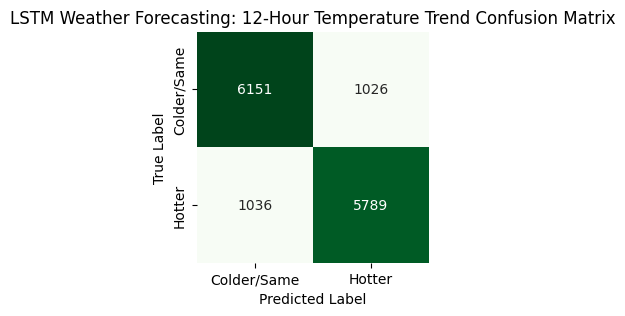

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

#prediction if colder/same or hoter
classes = classes = ['Colder/Same', 'Hotter']

#classification report
print("\n--- Classification Report ---")
print(classification_report(all_targets, all_preds, target_names=classes))

#confusion matrix
cm = confusion_matrix(all_targets, all_preds)
plot.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes,cbar=False)
plot.title('LSTM Weather Forecasting: 12-Hour Temperature Trend Confusion Matrix')
plot.xlabel('Predicted Label')
plot.ylabel('True Label')
plot.show()

# Classification report and Confusion matrix 

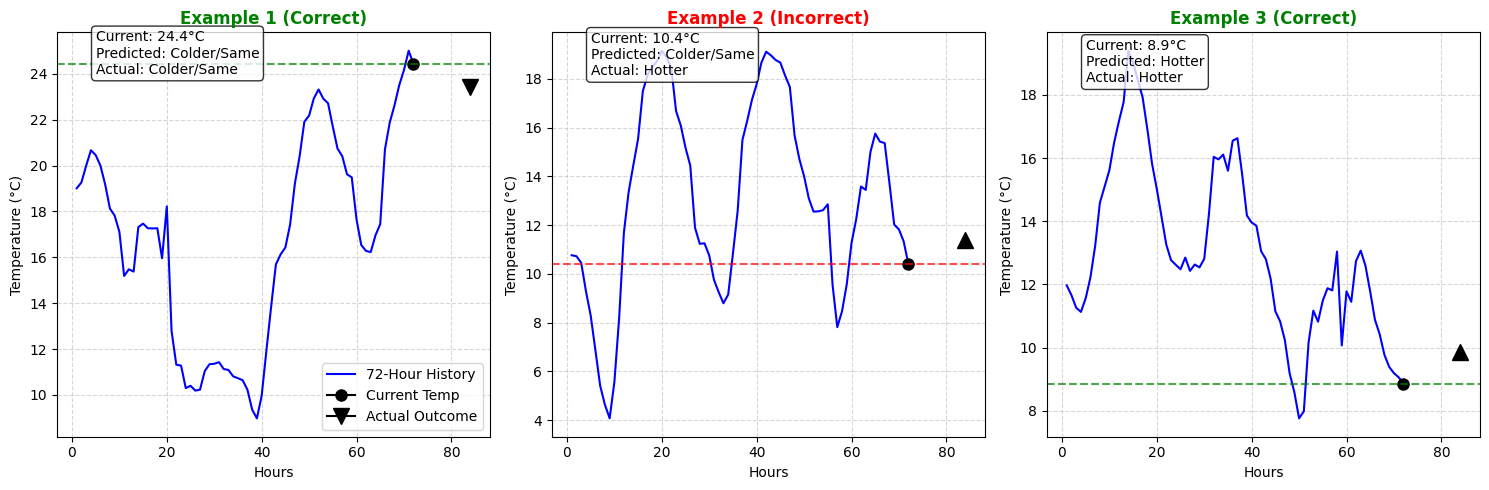

In [31]:
import random

# 1. Extract scaling parameters for 'T (degC)' (Index 1) to show real temperatures
temp_mean = scaler.mean_[1]
temp_std = scaler.scale_[1]

# 2. Put model in evaluation mode and fetch a sample block from the test set
model.eval()
inputs, labels = next(iter(test_loader))
inputs, labels = inputs.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(inputs)
    _, predictions = torch.max(outputs, 1)

# Convert to CPU numpy arrays for plotting
inputs_np = inputs.cpu().numpy()
labels_np = labels.cpu().numpy()
predictions_np = predictions.cpu().numpy()

# 3. Select 3 random indices from this batch to visualize
sample_indices = random.sample(range(len(inputs_np)), 3)

plot.figure(figsize=(15, 5))

for idx, sample_idx in enumerate(sample_indices):
    # Extract the 72-hour history for the temperature column (Index 1)
    scaled_history = inputs_np[sample_idx, :, 1]
    # Unscale back to real Celsius degrees
    unscaled_history = (scaled_history * temp_std) + temp_mean
    
    current_temp = unscaled_history[-1]
    true_trend = labels_np[sample_idx]
    pred_trend = predictions_np[sample_idx]
    
    # Define time axes for plotting
    history_hours = range(1, 73)
    future_hour = 84  # 72 hours of history + 12 hours offset
    
    # Create subplot
    plot.subplot(1, 3, idx + 1)
    plot.plot(history_hours, unscaled_history, label='72-Hour History', color='blue')
    plot.plot(72, current_temp, marker='o', color='black', markersize=8, label='Current Temp')
    
    # Determine annotation text and styling based on prediction accuracy
    pred_text = "Hotter" if pred_trend == 1 else "Colder/Same"
    true_text = "Hotter" if true_trend == 1 else "Colder/Same"
    is_correct = (pred_trend == true_trend)
    status_color = 'green' if is_correct else 'red'
    
    # 2. Visually plot the ACTUAL outcome at hour 84
    # If it actually got hotter, plot the marker slightly above the line. If colder, slightly below.
    outcome_y_pos = current_temp + 1 if true_trend == 1 else current_temp - 1
    outcome_marker = '^' if true_trend == 1 else 'v' # Up arrow for hotter, down arrow for colder
    plot.plot(84, outcome_y_pos, marker=outcome_marker, color='black', markersize=12, label='Actual Outcome')

    plot.axhline(y=current_temp, color=status_color, linestyle='--', alpha=0.7)
    
    # Place a text indicator on the chart detailing performance
    plot.title(f"Example {idx + 1} ({'Correct' if is_correct else 'Incorrect'})", color=status_color, fontweight='bold')
    plot.xlabel("Hours")
    plot.ylabel("Temperature (°C)")
    
    # Add an informational box with the comparative results
    info_text = f"Current: {current_temp:.1f}°C\nPredicted: {pred_text}\nActual: {true_text}"
    plot.text(5, max(unscaled_history) - 1, info_text, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plot.grid(True, linestyle='--', alpha=0.5)
    if idx == 0:
        plot.legend()

plot.tight_layout()
plot.show()

# Prediction Visuilation

**The Past Data (The Blue Line)**: This represents the model’s memory.It shows the specific 72 hour sequence of temperature peaks and valleys the LSTM analyzed to make its decision

**The Present (The Black Dot & Dashed Line)**: Hour 72 marks the exact moment of prediction. The dashed line extends the current temperature into the future, acting as a fixed threshold to measure whether the upcoming weather trend moves up or down.

**The Future (The Triangle)**: Placed 12 hours later (Hour 84), this symbol reveals the real-world outcome. If the triangle sits above the dashed line, the temperature rose. If it sits below, it dropped.

**The Verdict (Green vs. Red)**: The visualization acts as an instant grading system. If the model’s mathematical prediction (Hotter vs. Colder) correctly matches which side of the dashed line the triangle lands on, the chart turns Green. If the model is outsmarted by weather volatility, it turns Red.

In [38]:
torch.save(model.state_dict(), '/kaggle/working/LSTM_weights.pth')
print("Model weights saved successfully to /kaggle/working/LSTM_weights.pth!")

Model weights saved successfully to /kaggle/working/LSTM_weights.pth!
